In [1]:
import collections
from ortools.sat.python import cp_model

In [2]:
jobs_data = [  # task = (machine_id, processing_time).
    [(0, 3), (1, 2), (2, 2)],  # Job0
    [(0, 2), (2, 1), (1, 4)],  # Job1
    [(1, 4), (2, 3)],  # Job2
]

machines_count = 1 + max(task[0] for job in jobs_data for task in job)
all_machines = range(machines_count)
# Computes horizon dynamically as the sum of all durations.
horizon = sum(task[1] for job in jobs_data for task in job)

In [3]:
model = cp_model.CpModel()

In [4]:
# Named tuple to store information about created variables.
task_type = collections.namedtuple("task_type", "start end interval")
# Named tuple to manipulate solution information.
assigned_task_type = collections.namedtuple(
    "assigned_task_type", "start job index duration"
)

# Creates job intervals and add to the corresponding machine lists.
all_tasks = {}
machine_to_intervals = collections.defaultdict(list)

for job_id, job in enumerate(jobs_data):
    for task_id, task in enumerate(job):
        machine, duration = task
        suffix = f"_{job_id}_{task_id}"
        start_var = model.new_int_var(0, horizon, "start" + suffix)
        end_var = model.new_int_var(0, horizon, "end" + suffix)
        interval_var = model.new_interval_var(
            start_var, duration, end_var, "interval" + suffix
        )
        all_tasks[job_id, task_id] = task_type(
            start=start_var, end=end_var, interval=interval_var
        )
        machine_to_intervals[machine].append(interval_var)

In [5]:
# Create and add disjunctive constraints.
for machine in all_machines:
    model.add_no_overlap(machine_to_intervals[machine])

# Precedences inside a job.
for job_id, job in enumerate(jobs_data):
    for task_id in range(len(job) - 1):
        model.add(
            all_tasks[job_id, task_id + 1].start >= all_tasks[job_id, task_id].end
        )

In [6]:
# Makespan objective.
obj_var = model.new_int_var(0, horizon, "makespan")
model.add_max_equality(
    obj_var,
    [all_tasks[job_id, len(job) - 1].end for job_id, job in enumerate(jobs_data)],
)
model.minimize(obj_var)

In [7]:
solver = cp_model.CpSolver()
status = solver.solve(model)

In [8]:
if status == cp_model.OPTIMAL or status == cp_model.FEASIBLE:
    print("Solution:")
    # Create one list of assigned tasks per machine.
    assigned_jobs = collections.defaultdict(list)
    for job_id, job in enumerate(jobs_data):
        for task_id, task in enumerate(job):
            machine = task[0]
            assigned_jobs[machine].append(
                assigned_task_type(
                    start=solver.value(all_tasks[job_id, task_id].start),
                    job=job_id,
                    index=task_id,
                    duration=task[1],
                )
            )

    # Create per machine output lines.
    output = ""
    for machine in all_machines:
        # Sort by starting time.
        assigned_jobs[machine].sort()
        sol_line_tasks = "Machine " + str(machine) + ": "
        sol_line = "           "

        for assigned_task in assigned_jobs[machine]:
            name = f"job_{assigned_task.job}_task_{assigned_task.index}"
            # add spaces to output to align columns.
            sol_line_tasks += f"{name:15}"

            start = assigned_task.start
            duration = assigned_task.duration
            sol_tmp = f"[{start},{start + duration}]"
            # add spaces to output to align columns.
            sol_line += f"{sol_tmp:15}"

        sol_line += "\n"
        sol_line_tasks += "\n"
        output += sol_line_tasks
        output += sol_line

    # Finally print the solution found.
    print(f"Optimal Schedule Length: {solver.objective_value}")
    print(output)
else:
    print("No solution found.")

Solution:
Optimal Schedule Length: 11.0
Machine 0: job_0_task_0   job_1_task_0   
           [0,3]          [3,5]          
Machine 1: job_2_task_0   job_0_task_1   job_1_task_2   
           [0,4]          [4,6]          [6,10]         
Machine 2: job_1_task_1   job_2_task_1   job_0_task_2   
           [5,6]          [6,9]          [9,11]         



## 1. Robust Parser for flowshop1.txt Dataset

In [9]:
import re
import collections
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from ortools.sat.python import cp_model

In [10]:
def parse_flowshop1(file_path: str = "flowshop1.txt"):
    with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
        raw_lines = [line.strip() for line in f.readlines()]

    instances = []
    idx = 0
    total = len(raw_lines)

    # Skip all the lines at the beginning of the file until find the first 'instance' line
    while idx < total and not raw_lines[idx].startswith("instance"):
        idx += 1

    # Iteratively parse each instance (marked by 'instance')
    while idx < total:
        if raw_lines[idx].startswith("instance"):
            # Read instance name
            instance_name = raw_lines[idx].replace("instance", "").strip()
            idx += 1

            # skip ++++
            while idx < total and raw_lines[idx].startswith("+"):
                idx += 1

            # Find line with exactly 2 numbers: jobs count and machines count
            jobs_count, machines_count = 0, 0
            while idx < total:
                num_list = re.findall(r'\d+', raw_lines[idx])
                if len(num_list) == 2:
                    jobs_count = int(num_list[0])
                    machines_count = int(num_list[1])
                    idx += 1
                    break
                idx += 1

            # Read job processing data (strictly read jobs_count valid lines)
            # adjust OR-Tools input format
            jobs_data = []
            valid_lines = 0
            while valid_lines < jobs_count and idx < total:
                line = raw_lines[idx]
                nums = list(map(int, re.findall(r'\d+', line)))
                idx += 1

                if len(nums) >= 2 and len(nums) % 2 == 0:
                    # Extract the processing times bind to fixed machine IDs (0, 1, 2, ...)
                    # construct the standard format for the permutation flow shop.
                    process_times = [nums[i+1] for i in range(0, len(nums), 2)][:machines_count]
                    if len(process_times) == machines_count:
                        # Generate tuple format(machine_id, time)
                        job_with_machines = [(mid, t) for mid, t in enumerate(process_times)]
                        jobs_data.append(job_with_machines)
                        valid_lines += 1

            # Store valid instance
            if len(jobs_data) == jobs_count:
                instances.append({
                    "name": instance_name,
                    "jobs_count": jobs_count,
                    "machines_count": machines_count,
                    "jobs_data": jobs_data  # 标准元组格式，OR-Tools直接用
                })
        else:
            idx += 1
    return instances

In [11]:
fsp_instances = parse_flowshop1("flowshop1.txt")
print(f"Successfully loaded {len(fsp_instances)} FSP test instances")

print("\n===== All Instance Details =====")
for index, instance in enumerate(fsp_instances, start=1):
    print(f"Instance {index}:")
    print(f"  Name: {instance['name']}")
    print(f"  Jobs: {instance['jobs_count']} | Machines: {instance['machines_count']}")
    print(f"  Jobs_Data: {instance['jobs_data']}")
    print("-" * 40)


Successfully loaded 31 FSP test instances

===== All Instance Details =====
Instance 1:
  Name: car1
  Jobs: 11 | Machines: 5
  Jobs_Data: [[(0, 375), (1, 12), (2, 142), (3, 245), (4, 412)], [(0, 632), (1, 452), (2, 758), (3, 278), (4, 398)], [(0, 12), (1, 876), (2, 124), (3, 534), (4, 765)], [(0, 460), (1, 542), (2, 523), (3, 120), (4, 499)], [(0, 528), (1, 101), (2, 789), (3, 124), (4, 999)], [(0, 796), (1, 245), (2, 632), (3, 375), (4, 123)], [(0, 532), (1, 230), (2, 543), (3, 896), (4, 452)], [(0, 14), (1, 124), (2, 214), (3, 543), (4, 785)], [(0, 257), (1, 527), (2, 753), (3, 210), (4, 463)], [(0, 896), (1, 896), (2, 214), (3, 258), (4, 259)], [(0, 532), (1, 302), (2, 501), (3, 765), (4, 988)]]
----------------------------------------
Instance 2:
  Name: car2
  Jobs: 13 | Machines: 4
  Jobs_Data: [[(0, 654), (1, 147), (2, 345), (3, 447)], [(0, 321), (1, 520), (2, 789), (3, 702)], [(0, 12), (1, 147), (2, 630), (3, 255)], [(0, 345), (1, 586), (2, 214), (3, 866)], [(0, 678), (1, 532)

## 2.FSP Solver with OR-Tools CP-SAT
Based on official OR-Tools example, with solving time measurement

In [19]:
def solve_fsp_with_ortools(jobs_data):
    """
    Input: jobs_data = [[(machine_id, processing_time), ...], ...]
    Output: status, makespan (optimal completion time), solving_time (seconds), gantt chart data
    """
    start_time = time.time()
    
    machines_count = 1 + max(task[0] for job in jobs_data for task in job)
    all_machines = range(machines_count)
    horizon = sum(task[1] for job in jobs_data for task in job)

    # Create CP-SAT model
    model = cp_model.CpModel()
    task_type = collections.namedtuple("task_type", "start end interval")
    assigned_task_type = collections.namedtuple("assigned_task_type", "start job index duration")

    all_tasks = {}
    machine_to_intervals = collections.defaultdict(list)

    # Create variables for each task
    for job_id, job in enumerate(jobs_data):
        for task_id, task in enumerate(job):
            machine, duration = task
            suffix = f"_{job_id}_{task_id}"
            start_var = model.NewIntVar(0, horizon, "start" + suffix)
            end_var = model.NewIntVar(0, horizon, "end" + suffix)
            interval_var = model.NewIntervalVar(start_var, duration, end_var, "interval" + suffix)
            all_tasks[job_id, task_id] = task_type(start=start_var, end=end_var, interval=interval_var)
            machine_to_intervals[machine].append(interval_var)

    # Constraint 1: No overlapping tasks on the same machine
    for machine in all_machines:
        model.AddNoOverlap(machine_to_intervals[machine])

    # Constraint 2: Task sequence for each job
    for job_id, job in enumerate(jobs_data):
        for task_id in range(len(job) - 1):
            model.Add(all_tasks[job_id, task_id + 1].start >= all_tasks[job_id, task_id].end)

    # Objective: Minimize makespan (total completion time)
    obj_var = model.NewIntVar(0, horizon, "makespan")
    model.AddMaxEquality(obj_var, [all_tasks[job_id, len(job)-1].end for job_id, job in enumerate(jobs_data)])
    model.Minimize(obj_var)

    # Solve the model
    solver = cp_model.CpSolver()
    solver.parameters.max_time_in_seconds = 30
    status = solver.Solve(model)
    solving_time = round(time.time() - start_time, 4)

    # Parse results for Gantt chart
    gantt_data = collections.defaultdict(list)
    makespan = None

    if status in (cp_model.OPTIMAL, cp_model.FEASIBLE):
        makespan = solver.ObjectiveValue()
        for job_id, job in enumerate(jobs_data):
            for task_id, task in enumerate(job):
                machine = task[0]
                start = solver.Value(all_tasks[job_id, task_id].start)
                gantt_data[machine].append({
                    "job": job_id, 
                    "start": start, 
                    "duration": task[1]
                })
        
        # Sort tasks by start time for each machine
        for m in gantt_data:
            gantt_data[m].sort(key=lambda x: x["start"])

    return status, makespan, solving_time, gantt_data


In [20]:
def plot_fsp_gantt(gantt_data, machines_count, instance_name, makespan):
    """Plot Gantt chart for FSP scheduling results"""
    plt.rcParams["axes.unicode_minus"] = False
    fig, ax = plt.subplots(figsize=(12, 6))
    colors = plt.cm.Set3.colors

    for machine in range(machines_count):
        tasks = gantt_data.get(machine, [])
        y_pos = machines_count - machine - 1
        
        for task in tasks:
            job = task["job"]
            start = task["start"]
            dur = task["duration"]
            rect = mpatches.Rectangle(
                (start, y_pos-0.4), dur, 0.8, 
                facecolor=colors[job%len(colors)], 
                edgecolor="black"
            )
            ax.add_patch(rect)
            ax.text(start+dur/2, y_pos, f"J{job}", ha="center", va="center", fontsize=8)

    # Chart styling
    ax.set_xlim(0, makespan+10)
    ax.set_ylim(-0.5, machines_count-0.5)
    ax.set_yticks([machines_count - i - 1 for i in range(machines_count)])
    ax.set_yticklabels([f"Machine {i}" for i in range(machines_count)])
    ax.set_xlabel("Time Unit")
    ax.set_title(f"FSP Scheduling Gantt Chart\n{instance_name}\nMakespan: {makespan}")
    ax.grid(axis="x", linestyle="--", alpha=0.7)
    plt.tight_layout()
    plt.show()

In [21]:
import time

In [22]:
# for i, instance in enumerate(fsp_instances[:2]):
for i, instance in enumerate(fsp_instances):
    print("="*70)
    print(f"Solving Instance {i+1}: {instance['name']}")
    print(f"Jobs: {instance['jobs_count']} | Machines: {instance['machines_count']}")
    
    status, makespan, solving_time, gantt = solve_fsp_with_ortools(instance['jobs_data'])
    
    if status in (cp_model.OPTIMAL, cp_model.FEASIBLE):
        print(f"Solver Status: OPTIMAL" if status == cp_model.OPTIMAL else "✅ Solver Status: FEASIBLE")
        print(f"Solving Time: {solving_time} seconds")
        print(f"Optimal Makespan: {makespan}")
        # plot_fsp_gantt(gantt, instance['machines_count'], instance['name'], makespan)
    else:
        print("No solution found")
    print("="*70)

Solving Instance 1: car1
Jobs: 11 | Machines: 5
Solver Status: OPTIMAL
Solving Time: 0.1632 seconds
Optimal Makespan: 7038.0
Solving Instance 2: car2
Jobs: 13 | Machines: 4
Solver Status: OPTIMAL
Solving Time: 0.25 seconds
Optimal Makespan: 7166.0
Solving Instance 3: car3
Jobs: 12 | Machines: 5
Solver Status: OPTIMAL
Solving Time: 0.3491 seconds
Optimal Makespan: 7312.0
Solving Instance 4: car4
Jobs: 14 | Machines: 4
Solver Status: OPTIMAL
Solving Time: 0.2134 seconds
Optimal Makespan: 8003.0
Solving Instance 5: car5
Jobs: 10 | Machines: 6
Solver Status: OPTIMAL
Solving Time: 0.7811 seconds
Optimal Makespan: 7702.0
Solving Instance 6: car6
Jobs: 8 | Machines: 9
Solver Status: OPTIMAL
Solving Time: 0.604 seconds
Optimal Makespan: 8313.0
Solving Instance 7: car7
Jobs: 7 | Machines: 7
Solver Status: OPTIMAL
Solving Time: 0.2485 seconds
Optimal Makespan: 6558.0
Solving Instance 8: car8
Jobs: 8 | Machines: 8
Solver Status: OPTIMAL
Solving Time: 0.8268 seconds
Optimal Makespan: 8264.0
Solvin

The hel1 instance is a permutation flow shop scheduling problem with 100 jobs × 10 machines, containing a total of 100 × 10 = 1000 operations. Each operation requires defining start/end/interval variables. Combined with the machine non-overlapping constraints and precedence constraints between operations, the number of model variables and constraints grows exponentially.

For the NP-hard FSP problem, the time complexity of exact solvers (such as CP-SAT) increases exponentially with the number of jobs:
Small instances (e.g., car1 with 11 × 5): With few variables and simple constraints, CP-SAT can solve them in just a few milliseconds.
100 × 10 instance: With thousands of variables and constraints, CP-SAT may take hours or even days to find the optimal solution, and provides no feedback in a short period of time.

Solving Instance 1: car1
Jobs: 11 | Machines: 5
Solver Status: OPTIMAL
Solving Time: 0.1916 seconds
Optimal Makespan: 7038.0


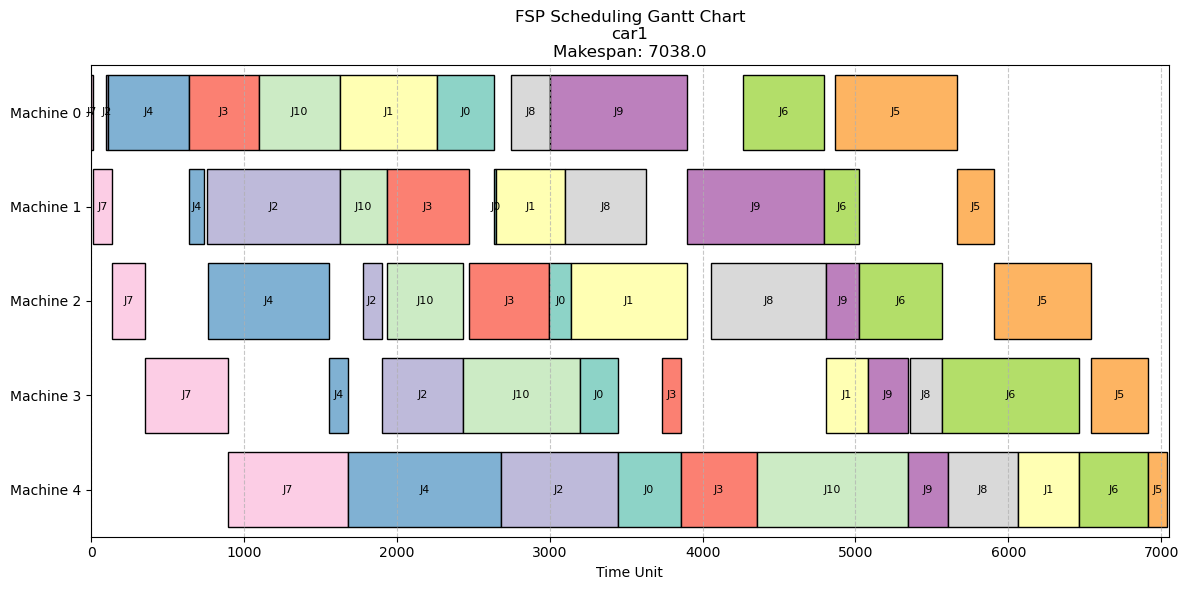

Solving Instance 2: car2
Jobs: 13 | Machines: 4
Solver Status: OPTIMAL
Solving Time: 0.166 seconds
Optimal Makespan: 7166.0


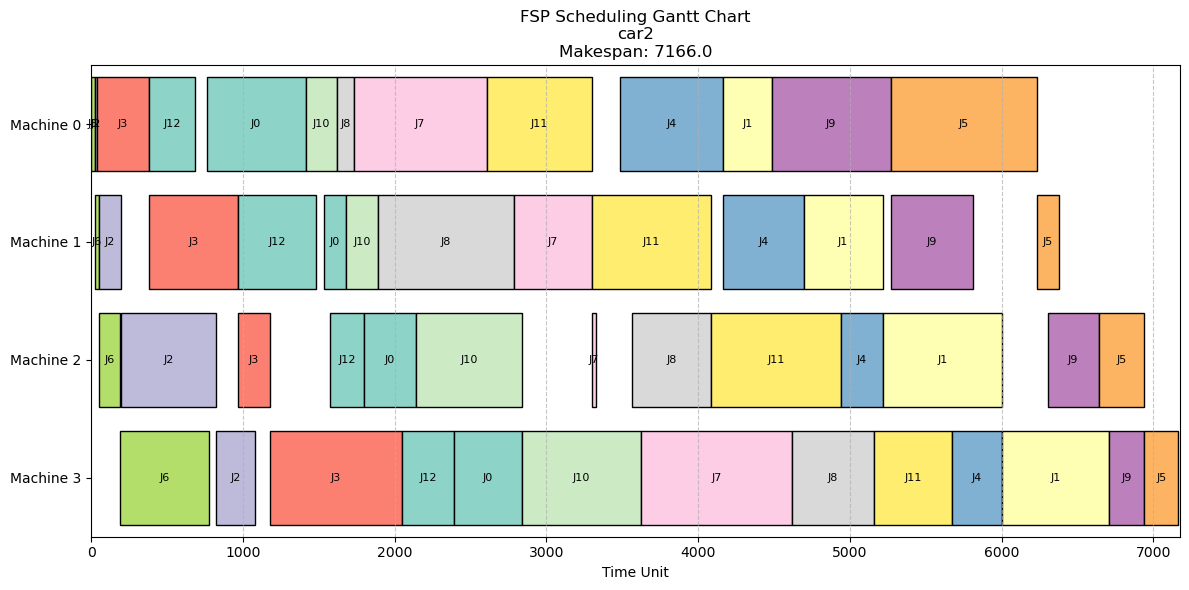

In [23]:
for i, instance in enumerate(fsp_instances[:2]):
# for i, instance in enumerate(fsp_instances):
    print("="*70)
    print(f"Solving Instance {i+1}: {instance['name']}")
    print(f"Jobs: {instance['jobs_count']} | Machines: {instance['machines_count']}")
    
    status, makespan, solving_time, gantt = solve_fsp_with_ortools(instance['jobs_data'])
    
    if status in (cp_model.OPTIMAL, cp_model.FEASIBLE):
        print(f"Solver Status: OPTIMAL" if status == cp_model.OPTIMAL else "✅ Solver Status: FEASIBLE")
        print(f"Solving Time: {solving_time} seconds")
        print(f"Optimal Makespan: {makespan}")
        plot_fsp_gantt(gantt, instance['machines_count'], instance['name'], makespan)
    else:
        print("No solution found")
    print("="*70)